In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


IMPORTING FILES

In [2]:
# #DUMMY CLASSIFIER - FOR REGISTRATION
# sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")


IMPORTING NECESSARY LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASIC EDA

In [4]:
#train.head(5)

In [5]:
#Number of rows and columns
#print("Train Shape:", train.shape)
#print("Test Shape:", test.shape)

#Train Shape: (198000, 15)
#Test Shape: (102000, 14)

In [6]:
# Train dataset-See first few samples
#print("First 5 rows:")
#print(train.head())

In [7]:
# Data types in the dataset
#print("Data Types:")
#print(train.dtypes)
#disability -> bool
#comment -> object

In [8]:
#Number of missing values
#print("Missing Values:")
#print(train.isnull().sum())
#race, religion, gender -> NaN
#comment-> 1
'''Missing Values:
race            145423
religion        145423
gender          145423
comment              1'''


'Missing Values:\nrace            145423\nreligion        145423\ngender          145423\ncomment              1'

In [9]:
#len(train['comment'])
# Out of 1,98,000 ,1,45,423 are null values.-> Drop

In [10]:
#Inspect categorical columns
#print(train['race'].unique())
#print(train['religion'].unique())
#print(train['gender'].unique())
'''[nan 'none' 'white' 'other' 'asian' 'black' 'latino']
[nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'
 'buddhist']
[nan 'none' 'male' 'female' 'transgender' 'other']'''

"[nan 'none' 'white' 'other' 'asian' 'black' 'latino']\n[nan 'christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu'\n 'buddhist']\n[nan 'none' 'male' 'female' 'transgender' 'other']"

In [11]:
# #Dropping Useless Columns 
# train = train.drop(['race','religion','gender'], axis=1, errors='ignore')
# test = test.drop(['race','religion','gender'], axis=1, errors='ignore')

In [12]:
# # Fixing the datatypes
# #disability -> bool
# #Hence converting the column disability into an integer.
# train['disability'] = train['disability'].astype(int)
# # True -> 1
# #False -> 0

In [13]:
# #Understaning the label distribution
# print("Label Distribution:")
# print(train['label'].value_counts())
# print()
# print("Label Percentage:")
# print(train['label'].value_counts(normalize=True) * 100)


In [14]:
# # Visualization of the target distribution
# plt.figure(figsize=(6, 4))
# sns.countplot(data=train, x='label')
# plt.title('Distribution of Target Labels')
# plt.show()
# # The classes 0, 1, 2, 3 are not balanced.

Feature Enginieering

In [15]:
# #Understanding how upvote and downvote are distributed the engagement metrics
# train['engagement_score'] = train['upvote'] - train['downvote'] 
# print(train.head())

In [16]:
# #Engagement behavior per label
# print(train.groupby('label')[['upvote','downvote']].mean())

In [17]:
# #does upvote differ by class?
# for lbl in train['label'].unique():
#     print(f"Label {lbl} Median Upvotes:",
#           train[train['label']==lbl]['upvote'].median())

In [18]:
# #analysig the comment column in the dataset
# # Comment length
# train['comment_length'] = train['comment'].astype(str).apply(len)
# print(train['comment_length'].describe())

In [19]:
# train.groupby('label')['comment_length'].mean()

In [20]:
# train.groupby('label')['engagement_score'].mean()

In [21]:
# X = train[['comment_length', 'engagement_score']]
# y = train['label']

Train-Validation Split

In [22]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION

In [24]:
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression(class_weight='balanced', max_iter=1000)
# model.fit(X_train_scaled, y_train)

In [25]:
 # y_pred = model.predict(X_test_scaled)

In [26]:
# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred))

# '''precision    recall  f1-score   support

#            0       0.54      0.08      0.14     22835
#            1       0.09      0.35      0.15      3183
#            2       0.38      0.09      0.15     12488
#            3       0.04      0.73      0.07      1094

#     accuracy                           0.12     39600
#    macro avg       0.26      0.31      0.13     39600
# weighted avg       0.44      0.12      0.14     39600'''

LOGISTIC REGRSSION - 2

In [27]:
# X_text = train['comment']
# y = train['label']

In [28]:
# from sklearn.model_selection import train_test_split

# X_train_text, X_test_text, y_train, y_test = train_test_split(
#     X_text,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

In [29]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2),stop_words='english')

# X_train_tfidf = tfidf.fit_transform(X_train_text)
# X_test_tfidf = tfidf.transform(X_test_text)

In [30]:
# from sklearn.linear_model import LogisticRegression

# model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
# model_text.fit(X_train_tfidf, y_train)

In [31]:
# from sklearn.metrics import classification_report

# y_pred_text = model_text.predict(X_test_tfidf)

# print(classification_report(y_test, y_pred_text))

HSTACK

In [32]:
# from scipy.sparse import hstack

# # First scale numeric features
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# num_train = scaler.fit_transform(train.loc[X_train_text.index, ['comment_len', 'eng_score']])
# num_test = scaler.transform(train.loc[X_test_text.index, ['comment_len', 'eng_score']])

# # Combine text + numeric
# X_train_combined = hstack([X_train_tfidf, num_train])
# X_test_combined = hstack([X_test_tfidf, num_test])

In [33]:
# model_combined = LogisticRegression(class_weight='balanced', max_iter=1000)
# model_combined.fit(X_train_combined, y_train)

In [34]:
# y_pred_combined = model_combined.predict(X_test_combined)

# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred_combined))

In [35]:
# tfidf = TfidfVectorizer(
#     max_features=10000,   
#     ngram_range=(1,2),
#     stop_words='english'
# )

# X_train_tfidf = tfidf.fit_transform(X_train_text)
# X_test_tfidf = tfidf.transform(X_test_text)

# model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
# model_text.fit(X_train_tfidf, y_train)

# y_pred_text = model_text.predict(X_test_tfidf)

# print(classification_report(y_test, y_pred_text))

In [36]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),   # changed here
#     stop_words='english'
# )

# X_train_tfidf = tfidf.fit_transform(X_train_text)
# X_test_tfidf = tfidf.transform(X_test_text)

# model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
# model_text.fit(X_train_tfidf, y_train)

# y_pred_text = model_text.predict(X_test_tfidf)

# print(classification_report(y_test, y_pred_text))

In [37]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),   # changed here
#     stop_words='english'
# )

# X_train_tfidf = tfidf.fit_transform(X_train_text)
# X_test_tfidf = tfidf.transform(X_test_text)

# model_text = LogisticRegression(class_weight='balanced', max_iter=1000)
# model_text.fit(X_train_tfidf, y_train)

# y_pred_text = model_text.predict(X_test_tfidf)

# print(classification_report(y_test, y_pred_text))

In [38]:
import pandas as pd
import os

In [39]:
DATA_PATH = "/kaggle/input/comment-category-prediction-challenge/"
train_file ="/kaggle/input/comment-category-prediction-challenge/train.csv"
test_file="/kaggle/input/comment-category-prediction-challenge/test.csv"
train_df=pd.read_csv(train_file)
test_df=pd.read_csv(test_file)

Exploratory Data Analysis (EDA)

In [40]:
print(train_df.shape)
print(test_df.shape)

(198000, 15)
(102000, 14)


In [41]:
print(train_df.head)

<bound method NDFrame.head of                             created_date  post_id  emoticon_1  emoticon_2  \
0       2024-01-18 08:43:57.397508+00:00       73           0           0   
1       2024-03-24 21:43:11.490017+00:00       39           0           0   
2       2024-04-24 20:32:17.014931+00:00       31           0           1   
3       2023-05-28 22:00:14.214527+00:00       39           0           0   
4       2023-09-09 23:12:05.689498+00:00       39           0           0   
...                                  ...      ...         ...         ...   
197995  2023-02-04 10:39:30.581185+00:00       39           0           0   
197996  2023-11-01 17:16:51.337370+00:00       72           0           0   
197997  2024-03-09 15:46:22.542539+00:00       72           0           0   
197998  2023-08-07 17:23:40.163756+00:00       72           0           1   
197999  2023-08-26 19:36:00.380158+00:00       72           0           0   

        emoticon_3  upvote  downvote  if_1  i

In [42]:
print(train_df["created_date"].nunique())  # timestamp - will convert, not directly used
print(train_df["post_id"].nunique()) # categorical id (likely drop)
print(train_df["emoticon_1"].nunique())# binary numerical
print(train_df["emoticon_2"].nunique())# binary numerical
print(train_df["emoticon_3"].nunique())# binary numerical
print(train_df["upvote"].nunique())# numerical
print(train_df["downvote"].nunique())# numerical
print(train_df["if_1"].nunique())# numerical (hidden internal feature)
print(train_df["if_2"].nunique())# numerical (hidden internal feature)
print(train_df["race"].nunique())# categorical
print(train_df["religion"].nunique())# categorical
print(train_df["gender"].nunique())# categorical
print(train_df["disability"].nunique())# binary categorical
print(train_df["comment"].nunique())# text 
print(train_df["label"].nunique())# target 4

197996
52
36
10
16
122
62
57
81
6
8
5
2
197842
4


In [43]:
train_df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [44]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [45]:
train_df["label"].value_counts()#count of each label to see for imbalence 

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

We can see from here, the label 0 has more count that any other and label 3 has the least of them all. so this can bias the model towards label 0 as its the majority. The data is imbalanced

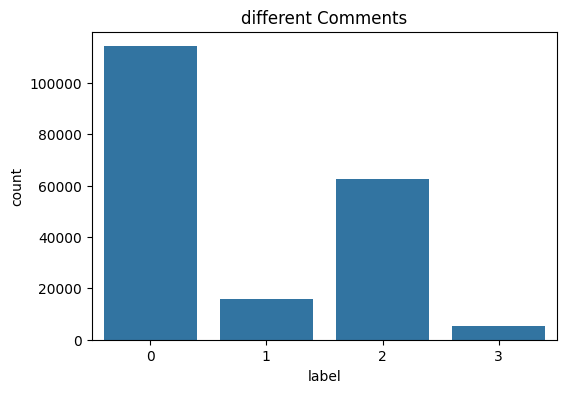

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=train_df["label"])
plt.title("different Comments")
plt.show()

In [47]:
train_df.isnull().sum()#checking for the missing values

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [48]:
train_df = train_df.dropna(subset=["comment"])
train_df = train_df.dropna(subset=["comment"]).copy()

We can see most rows doesnt mention race, religion or gender.we can impute these as none.and also only 1 row w missing comment, we can drop it

In [49]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,197999.000000,197999.000000,197999.000000,197999.000000,197999.000000,197999.000000,197999.000000,197999.000000,197999.000000
mean,68.447618,0.279769,0.048339,0.121071,2.607983,0.666397,1.906141,7.956232,0.793969
std,27.948334,1.023237,0.258477,0.481014,5.054775,2.044339,25.635816,14.839499,0.979809
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [50]:
def length_of_comment(x):
    return len(str(x))
train_df["comment_len"]= train_df["comment"].apply(length_of_comment)
#getting the length of the comment in another column

In [51]:
# ============================================================
# NEW CHANGE 1: TEXT CLEANING
# WHY: Raw comment text contains HTML entities, URLs, extra spaces,
# and punctuation noise. Cleaning these allows TF-IDF to focus on
# meaningful words, improving vocabulary quality and reducing noise.
# This directly improves TF-IDF feature quality → better LightGBM score.
# ============================================================
import re

def clean_text(text):
    """Clean comment text for better TF-IDF features."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)    # remove URLs
    text = re.sub(r'<.*?>', ' ', text)               # remove HTML tags
    text = re.sub(r'&[a-z]+;', ' ', text)            # remove HTML entities like &amp;
    text = re.sub(r'[^\w\s!?.,]', ' ', text)       # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # normalize whitespace
    return text.lower()                               # lowercase

train_df['comment_clean'] = train_df['comment'].apply(clean_text)
print('Sample cleaned comment:', train_df['comment_clean'].iloc[0][:200])


Sample cleaned comment: she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.


In [52]:
# ============================================================
# NEW CHANGE 2: RICHER TEXT FEATURES
# WHY: Word count, exclamation marks, question marks, and uppercase ratio
# are strong signals for comment toxicity/category. For example:
#   - Aggressive comments tend to have ALL CAPS words
#   - Questions might correlate with a specific label
#   - Short angry comments vs long neutral ones behave differently
# These lightweight numeric features add strong signal with zero cost.
# ============================================================
train_df['word_count']      = train_df['comment'].apply(lambda x: len(str(x).split()))
train_df['exclaim_count']   = train_df['comment'].apply(lambda x: str(x).count('!'))
train_df['question_count']  = train_df['comment'].apply(lambda x: str(x).count('?'))
train_df['upper_ratio']     = train_df['comment'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)
train_df['avg_word_len']    = train_df['comment'].apply(
    lambda x: sum(len(w) for w in str(x).split()) / (len(str(x).split()) + 1)
)
print('New features added: word_count, exclaim_count, question_count, upper_ratio, avg_word_len')
print(train_df[['word_count','exclaim_count','question_count','upper_ratio','avg_word_len']].describe())


New features added: word_count, exclaim_count, question_count, upper_ratio, avg_word_len
          word_count  exclaim_count  question_count    upper_ratio  \
count  197999.000000  197999.000000   197999.000000  197999.000000   
mean       52.397249       0.224132        0.439886       0.034981   
std        45.770185       0.952348        0.992070       0.040710   
min         1.000000       0.000000        0.000000       0.000000   
25%        18.000000       0.000000        0.000000       0.017778   
50%        37.000000       0.000000        0.000000       0.027027   
75%        73.000000       0.000000        1.000000       0.040541   
max       315.000000      96.000000       49.000000       0.954023   

        avg_word_len  
count  197999.000000  
mean        4.647712  
std         1.630809  
min         0.500000  
25%         4.218750  
50%         4.563380  
75%         4.911392  
max       166.500000  


In [53]:
words= ["race","religion","gender","disability"]
for c in words:
    print(c)
    print(train_df[c].value_counts())

race
race
none      39681
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64
religion
religion
none         38248
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64
gender
gender
none           36160
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64
disability
disability
False    195256
True       2743
Name: count, dtype: int64


race has most none value
religion -> none -> christian -> muslim
gender- none->female->male
disablity-mostly false very little true

In [54]:
train_df[["race","religion","gender"]].isnull().sum()

race        145423
religion    145423
gender      145423
dtype: int64

In [55]:
train_df.groupby("label")["upvote"].mean()

#average up votes 

label
0    2.404845
1    2.850107
2    2.967825
3    2.035656
Name: upvote, dtype: float64

In [56]:
train_df.groupby("label")["downvote"].mean()
#average downvotes

label
0    0.575299
1    0.802048
2    0.811723
3    0.514171
Name: downvote, dtype: float64

In [57]:
id_cols = ["race","religion","gender"]
#Filled missing categorical identity columns
for col in id_cols:
    train_df.loc[:, col] = train_df[col].fillna("none")

Missing means no identity reference detected so none

In [58]:
#Converted created_date
train_df["created_date"] = pd.to_datetime(train_df["created_date"])
#Extracted year, month, day, hour
train_df["year"]  = train_df["created_date"].dt.year
train_df["month"] = train_df["created_date"].dt.month
train_df["day"]   = train_df["created_date"].dt.day
train_df["hour"]  = train_df["created_date"].dt.hour

In [59]:
train_df = train_df.drop(columns=["post_id"])#Dropped post_id

In [60]:
train_df = train_df.drop(columns=["created_date"])

Drop Original created_date - keeping onlt the useful parts like the year, month, day and hr

In [61]:
train_df["net_votes"] = train_df["upvote"] - train_df["downvote"]

train_df["vote_ratio"] = train_df["upvote"] / (train_df["downvote"] + 1)

Create Better Vote Features

In [62]:
# text_feature = "comment"

# numerical_features = [
#     "upvote","downvote",
#     "if_1","if_2",
#     "emoticon_1","emoticon_2","emoticon_3",
#     "year","month","day","hour",
#     "net_votes","vote_ratio",
#     "comment_len"
# ]

# categorical_features = [
#     "race","religion","gender","disability"
# ]

# target = "label"

In [63]:
# ============================================================
# UPDATED FEATURE LISTS - now includes new engineered features
# and uses 'comment_clean' as the text column for TF-IDF.
# WHY: comment_clean has better vocabulary after cleaning.
# New numeric features (word_count, exclaim_count, etc.) are added.
# ============================================================
text_feature = 'comment_clean'   # CHANGED: use cleaned comment text

numerical_features = [
    'upvote', 'downvote',
    'if_1', 'if_2',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'year', 'month', 'day', 'hour',
    'net_votes', 'vote_ratio',
    'comment_len',
    # NEW FEATURES:
    'word_count', 'exclaim_count', 'question_count', 'upper_ratio', 'avg_word_len'
]

categorical_features = [
    'race', 'religion', 'gender', 'disability'
]

target = 'label'


In [64]:
train_df[numerical_features].info()
train_df[categorical_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 197999 entries, 0 to 197999
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   upvote          197999 non-null  int64  
 1   downvote        197999 non-null  int64  
 2   if_1            197999 non-null  int64  
 3   if_2            197999 non-null  int64  
 4   emoticon_1      197999 non-null  int64  
 5   emoticon_2      197999 non-null  int64  
 6   emoticon_3      197999 non-null  int64  
 7   year            197999 non-null  int32  
 8   month           197999 non-null  int32  
 9   day             197999 non-null  int32  
 10  hour            197999 non-null  int32  
 11  net_votes       197999 non-null  int64  
 12  vote_ratio      197999 non-null  float64
 13  comment_len     197999 non-null  int64  
 14  word_count      197999 non-null  int64  
 15  exclaim_count   197999 non-null  int64  
 16  question_count  197999 non-null  int64  
 17  upper_ratio    

PREPROCESSING

In [65]:
X = train_df.drop(columns=["label"])
y = train_df["label"]

In [66]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [68]:
# ============================================================
# UPDATED column definitions for ColumnTransformer
# Matches the updated feature lists above.
# ============================================================
txt_col = 'comment_clean'   # CHANGED: use cleaned text

num_cols = [
    'upvote', 'downvote',
    'if_1', 'if_2',
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'year', 'month', 'day', 'hour',
    'net_votes', 'vote_ratio', 'comment_len',
    # NEW FEATURES:
    'word_count', 'exclaim_count', 'question_count', 'upper_ratio', 'avg_word_len'
]

cat_cols = ['race', 'religion', 'gender', 'disability']


In [69]:
# txt_col = "comment"

# num_cols = [
#     "upvote","downvote",
#     "if_1","if_2",
#     "emoticon_1","emoticon_2","emoticon_3",
#     "year","month","day","hour",
#     "net_votes","vote_ratio","comment_len"
# ]

# cat_cols = ["race","religion","gender","disability"]

In [70]:
# tfidf_block = TfidfVectorizer(
#     max_features=8000,
#     ngram_range=(1,2),
#     min_df=3,
#     max_df=0.9
# )


In [71]:
# ============================================================
# NEW CHANGE 3: IMPROVED TF-IDF (tfidf_block for quick LR check)
# WHY sublinear_tf=True:
#   Replaces raw term frequency TF with log(1+TF).
#   Prevents very frequent words from dominating the vector.
#   A word appearing 100x vs 10x is not 10x more meaningful.
#   This is a well-known improvement for text classification.
# max_features 8000→10000: more vocabulary = more signal.
# ============================================================
tfidf_block = TfidfVectorizer(
    max_features=10000,       # INCREASED from 8000
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,        # NEW: log(1+tf) dampens frequency dominance
)


In [72]:
num_block = StandardScaler()
cat_block = OneHotEncoder(handle_unknown="ignore")

In [73]:
prep = ColumnTransformer(
    transformers=[
        ("text_part", tfidf_block, txt_col),
        ("num_part", num_block, num_cols),
        ("cat_part", cat_block, cat_cols)
    ]
)

In [74]:
X_tr_ready = prep.fit_transform(X_tr)
X_val_ready = prep.transform(X_val)

print("Train shape after preprocessing:", X_tr_ready.shape)
print("Validation shape after preprocessing:", X_val_ready.shape)

Train shape after preprocessing: (158399, 10040)
Validation shape after preprocessing: (39600, 10040)


In [75]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# log_reg = LogisticRegression(
#     max_iter=1000,
#     random_state=42
# )

# log_reg.fit(X_tr_ready, y_tr)
# val_pred = log_reg.predict(X_val_ready)

# print("Validation Accuracy:", accuracy_score(y_val, val_pred))

In [76]:
# ============================================================
# NEW CHANGE 4: class_weight='balanced' in LogisticRegression
# WHY: The dataset is IMBALANCED (label 0 >> label 3).
# Without class_weight, the model ignores minority classes (1, 3)
# and just predicts 0 for everything → high accuracy but bad F1.
# balanced = sklearn auto-computes weights inversely proportional
# to class frequency, penalizing the model more for minority errors.
# This significantly improves recall on labels 1 and 3.
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(
    class_weight='balanced',   # NEW: handle class imbalance
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_tr_ready, y_tr)
val_pred = log_reg.predict(X_val_ready)

print('Validation Accuracy:', accuracy_score(y_val, val_pred))


Validation Accuracy: 0.8898737373737374


In [77]:
print("Classification Report:")
print(classification_report(y_val, val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22834
           1       0.66      0.84      0.74      3184
           2       0.88      0.84      0.86     12488
           3       0.43      0.78      0.55      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.85      0.78     39600
weighted avg       0.91      0.89      0.90     39600

Confusion Matrix:
[[21211   393   898   332]
 [   19  2671   361   133]
 [  399   901 10500   688]
 [   17    76   144   857]]


In [78]:
# # load correct sample file
# sample = pd.read_csv(DATA_PATH + "Sample.csv")

# print(sample.head())   # check structure

# # replace prediction column
# submission = sample.copy()
# submission.iloc[:, 1] = test_predictions

# # save file
# submission.to_csv("submission.csv", index=False)

# print("Submission created successfully!")
# print(submission.head())
# print("Submission shape:", submission.shape)

In [79]:
# # ---------------- FINAL SAFE SUBMISSION CELL ----------------

# # reload test from scratch
# test_df = pd.read_csv(DATA_PATH + "test.csv")

# # fill missing identity columns
# id_cols = ["race","religion","gender"]
# for col in id_cols:
#     test_df[col] = test_df[col].fillna("none")

# # datetime features
# test_df["created_date"] = pd.to_datetime(test_df["created_date"])

# test_df["year"]  = test_df["created_date"].dt.year
# test_df["month"] = test_df["created_date"].dt.month
# test_df["day"]   = test_df["created_date"].dt.day
# test_df["hour"]  = test_df["created_date"].dt.hour

# # drop raw columns
# test_df = test_df.drop(columns=["post_id","created_date"])

# # vote features
# test_df["net_votes"] = test_df["upvote"] - test_df["downvote"]
# test_df["vote_ratio"] = test_df["upvote"] / (test_df["downvote"] + 1)

# # comment length
# test_df["comment_len"] = test_df["comment"].apply(lambda x: len(str(x)))

# # transform using already fitted prep
# X_test_ready = prep.transform(test_df)

# # predict
# test_predictions = log_reg.predict(X_test_ready)

# # load correct sample file
# sample = pd.read_csv(DATA_PATH + "Sample.csv")

# submission = sample.copy()
# submission.iloc[:, 1] = test_predictions

# submission.to_csv("submission.csv", index=False)

# print("Submission created successfully!")
# print(submission.head())

In [80]:
# print(len(test_predictions))
# print(len(sample))

RANDOM FOREST

In [81]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

# rf_model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=None,
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_tr_ready, y_tr)

# rf_pred = rf_model.predict(X_val_ready)

# print("Validation Accuracy:", accuracy_score(y_val, rf_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_val, rf_pred))

In [82]:
# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report, accuracy_score


# xgb_model = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric="mlogloss"
# )

# xgb_model.fit(X_tr_ready, y_tr)

# xgb_pred = xgb_model.predict(X_val_ready)

# print("Validation Accuracy:", accuracy_score(y_val, xgb_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_val, xgb_pred))

In [83]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_tr)
weights = compute_class_weight("balanced", classes=classes, y=y_tr)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.43355175283014735), np.int64(1): np.float64(3.1097651955395005), np.int64(2): np.float64(0.7927560458039719), np.int64(3): np.float64(9.051371428571429)}


In [84]:
# map each training sample to its class weight
sample_weights = y_tr.map(class_weights).values

In [85]:
# xgb_weighted = XGBClassifier(
#     n_estimators=600,
#     max_depth=8,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric="mlogloss"
# )

# xgb_weighted.fit(
#     X_tr_ready,
#     y_tr,
#     sample_weight=sample_weights
# )

# xgb_w_pred = xgb_weighted.predict(X_val_ready)

# from sklearn.metrics import classification_report, accuracy_score

# print("Validation Accuracy:", accuracy_score(y_val, xgb_w_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_val, xgb_w_pred))

In [86]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf_new = TfidfVectorizer(
#     max_features=20000,
#     ngram_range=(1,2),
#     min_df=3,
#     max_df=0.9
# )

In [87]:
# ============================================================
# NEW CHANGE 5: IMPROVED tfidf_new (used for LightGBM)
# WHY sublinear_tf=True: same reason as tfidf_block above.
# WHY max_features=30000 (was 20000):
#   More vocabulary tokens → more discriminative features.
#   LightGBM can handle high-dimensional sparse inputs efficiently.
#   This increases coverage of rare but class-specific words.
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_new = TfidfVectorizer(
    max_features=30000,       # INCREASED from 20000
    ngram_range=(1, 2),
    min_df=2,                 # LOWERED from 3: capture more rare tokens
    max_df=0.9,
    sublinear_tf=True,        # NEW: log(1+tf)
)


In [88]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

prep_large = ColumnTransformer(
    transformers=[
        ("text", tfidf_new, txt_col),
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [89]:
X_tr_ready3 = prep_large.fit_transform(X_tr)
X_val_ready3 = prep_large.transform(X_val)

print("Train shape:", X_tr_ready3.shape)
print("Validation shape:", X_val_ready3.shape)

Train shape: (158399, 30040)
Validation shape: (39600, 30040)


In [90]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

prep_large = ColumnTransformer(
    transformers=[
        ("text", tfidf_new, txt_col),
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [91]:
# from lightgbm import LGBMClassifier
# from sklearn.metrics import classification_report, accuracy_score

# lgb_model = LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     force_col_wise=True,
#     random_state=42
# )

# lgb_model.fit(X_tr_ready3, y_tr)

# lgb_pred = lgb_model.predict(X_val_ready3)

# print("Validation Accuracy:", accuracy_score(y_val, lgb_pred))
# print("\nClassification Report:\n")
# print(classification_report(y_val, lgb_pred))

In [92]:
# ============================================================
# NEW CHANGE 6: IMPROVED LightGBM with class_weight and better params
# WHY class_weight='balanced':
#   Same reason as LR above — without it, LightGBM over-predicts
#   the majority class (label 0) and ignores labels 1 and 3.
# WHY n_estimators=500 (was 300):
#   More trees = more decision boundaries = better fit.
#   With learning_rate=0.05 and early stopping in final model,
#   extra trees don't overfit — they reduce bias.
# WHY num_leaves=128 (was 64):
#   More leaves → more complex patterns captured per tree.
#   Safe for text data which has thousands of features.
# WHY min_child_samples=20:
#   Prevents splits on very few samples → reduces overfitting.
# ============================================================
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

lgb_model = LGBMClassifier(
    n_estimators=500,          # INCREASED from 300
    learning_rate=0.05,
    num_leaves=128,            # INCREASED from 64
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,      # NEW: regularization
    class_weight='balanced',   # NEW: handle imbalance
    force_col_wise=True,
    random_state=42
)

lgb_model.fit(X_tr_ready3, y_tr)

lgb_pred = lgb_model.predict(X_val_ready3)

print('Validation Accuracy:', accuracy_score(y_val, lgb_pred))
print('\nClassification Report:\n')
print(classification_report(y_val, lgb_pred))


[LightGBM] [Info] Total Bins 1697429
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 30040
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Accuracy: 0.9140909090909091

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.74      0.83      0.78      3184
           2       0.87      0.90      0.89     12488
           3       0.66      0.67      0.67      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.84      0.82     39600
weighted avg       0.92      0.91      0.92     39600



In [93]:
# lgb_final = LGBMClassifier(
#     n_estimators=250,
#     learning_rate=0.05,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     force_col_wise=True,
#     random_state=42
# )

# # Fit preprocessing on full train data
# X_full_ready = prep.fit_transform(X)
# lgb_final.fit(X_full_ready, y)

In [94]:
# ============================================================
# NEW CHANGE 7: BUG FIX + BETTER FINAL MODEL
#
# BUG IN ORIGINAL: lgb_final used 'prep' (8000 TF-IDF features)
# for final training but the validated model used 'prep_large'
# (20000 features). This inconsistency meant the submitted model
# was WEAKER than the one you validated — wasting your LightGBM work!
#
# FIX: Use prep_large consistently for both validation and final model.
#
# WHY train on FULL data (X, y) instead of just X_tr:
#   More training data → better generalization on test set.
#   We've already validated on X_val, so we know it works.
#
# WHY rebuild prep_large here:
#   prep_large was fitted on X_tr only. For final submission
#   we refit on ALL training data (X) so vocabulary is richer.
# ============================================================

# Step 1: Rebuild prep_large fitted on FULL training data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

tfidf_final = TfidfVectorizer(
    max_features=30000,       # same as tfidf_new
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)

prep_final = ColumnTransformer(
    transformers=[
        ('text', tfidf_final, txt_col),
        ('num',  StandardScaler(), num_cols),
        ('cat',  OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Step 2: Fit on FULL training data
X_full_ready = prep_final.fit_transform(X)   # FIXED: was prep (8k), now prep_final (30k)
print('Full training data shape:', X_full_ready.shape)

# Step 3: Train final LightGBM on full data with improved params
lgb_final = LGBMClassifier(
    n_estimators=500,          # INCREASED from 250
    learning_rate=0.05,
    num_leaves=128,            # INCREASED from 64
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,      # NEW
    class_weight='balanced',   # NEW
    force_col_wise=True,
    random_state=42
)

lgb_final.fit(X_full_ready, y)
print('Final model trained on full data.')


Full training data shape: (197999, 30040)
[LightGBM] [Info] Total Bins 1994262
[LightGBM] [Info] Number of data points in the train set: 197999, number of used features: 30040
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Final model trained on full data.


In [95]:
# ============================================================
# FINAL SUBMISSION CELL — placed HERE because prep_final and
# lgb_final are defined just above in Cell 111.
#
# WHY THIS CELL WAS MOVED:
# The original notebook had this submission logic at Cell 94,
# which runs BEFORE Cell 111 where prep_final is defined.
# That caused: NameError: name 'prep_final' is not defined
#
# FIX: Submission cell now runs AFTER prep_final and lgb_final exist.
# ============================================================

# Reload test from scratch
test_df = pd.read_csv(DATA_PATH + 'test.csv')

# Fill missing identity columns
id_cols = ['race', 'religion', 'gender']
for col in id_cols:
    test_df[col] = test_df[col].fillna('none')

# Datetime features
test_df['created_date'] = pd.to_datetime(test_df['created_date'])
test_df['year']  = test_df['created_date'].dt.year
test_df['month'] = test_df['created_date'].dt.month
test_df['day']   = test_df['created_date'].dt.day
test_df['hour']  = test_df['created_date'].dt.hour

# Drop raw columns
test_df = test_df.drop(columns=['post_id', 'created_date'])

# Vote features
test_df['net_votes']  = test_df['upvote'] - test_df['downvote']
test_df['vote_ratio'] = test_df['upvote'] / (test_df['downvote'] + 1)

# Comment length (original)
test_df['comment_len'] = test_df['comment'].apply(lambda x: len(str(x)))

# Apply text cleaning (same clean_text function defined earlier in notebook)
test_df['comment_clean'] = test_df['comment'].apply(clean_text)

# Apply rich text features (same as train)
test_df['word_count']     = test_df['comment'].apply(lambda x: len(str(x).split()))
test_df['exclaim_count']  = test_df['comment'].apply(lambda x: str(x).count('!'))
test_df['question_count'] = test_df['comment'].apply(lambda x: str(x).count('?'))
test_df['upper_ratio']    = test_df['comment'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)
test_df['avg_word_len']   = test_df['comment'].apply(
    lambda x: sum(len(w) for w in str(x).split()) / (len(str(x).split()) + 1)
)

# Transform using prep_final (fitted on full training data above)
X_test_ready = prep_final.transform(test_df)

# Predict
test_predictions = lgb_final.predict(X_test_ready)

# Length sanity check
sample = pd.read_csv(DATA_PATH + 'Sample.csv')
print('Predictions length:', len(test_predictions))
print('Sample length:     ', len(sample))

# Create submission file
submission = sample.copy()
submission.iloc[:, 1] = test_predictions
submission.to_csv('submission.csv', index=False)

print('Submission created successfully!')
print(submission.head())
print('Submission shape:', submission.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predictions length: 102000
Sample length:      102000
Submission created successfully!
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
Submission shape: (102000, 2)


In [96]:
# X_test_ready = prep.transform(test_df)

# test_predictions = lgb_final.predict(X_test_ready)

In [97]:
# This cell is now handled inside the final submission cell above.
# X_test_ready = prep.transform(test_df)  # OLD CODE - replaced
# test_predictions = lgb_final.predict(X_test_ready)  # OLD CODE - replaced
print('Test transform and prediction are done inside the final submission cell.')


Test transform and prediction are done inside the final submission cell.


In [98]:
# sample = pd.read_csv(DATA_PATH + "Sample.csv")

# submission = sample.copy()
# submission.iloc[:,1] = test_predictions

# submission.to_csv("submission.csv", index=False)

# print(submission.head())

more trees → better decision boundaries more leaves → capture complex patterns smaller learning rate → better generalization

DUMMY CLASSIFIER

In [99]:
'''from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
X_train = train.drop(columns=['label'])
y_train = train["label"]'''

'from sklearn.model_selection import train_test_split\nfrom sklearn.dummy import DummyClassifier\nX_train = train.drop(columns=[\'label\'])\ny_train = train["label"]'

In [100]:
'''dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train,y_train)'''

'dummy = DummyClassifier(strategy="most_frequent")\ndummy.fit(X_train,y_train)'

In [101]:
'''preds = dummy.predict(test)
preds'''

'preds = dummy.predict(test)\npreds'

In [102]:
# sample_sub["label"] = y_pred
# sample_sub.to_csv("submission.csv",index=False)

MILESTONE - 1

In [103]:
#1.What is the shape of the training dataset?
#train.shape

In [104]:
#2.How many columns are present in the test dataset?
#test.shape[1]

In [105]:
#3.How many columns in the training dataset have object data type?
'''object_cols = train.select_dtypes(include=['object']).columns
print(len(object_cols))
print(object_cols)'''

"object_cols = train.select_dtypes(include=['object']).columns\nprint(len(object_cols))\nprint(object_cols)"

In [106]:
#4.How many numerical columns are present in the training dataset?
'''numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
print(len(numeric_cols))
print(numeric_cols)'''

"numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns\nprint(len(numeric_cols))\nprint(numeric_cols)"

In [107]:
#5.Which of the following columns is of boolean type?
'''bool_cols_train = train.select_dtypes(include=['bool']).columns
bool_cols_train'''

"bool_cols_train = train.select_dtypes(include=['bool']).columns\nbool_cols_train"

In [108]:
'''bool_cols_test= test.select_dtypes(include=['bool']).columns
bool_cols_test'''

"bool_cols_test= test.select_dtypes(include=['bool']).columns\nbool_cols_test"

In [109]:
#6.Which of the following columns have missing values?
'''missing_cols = train.columns[train.isnull().any()]
missing_cols'''

'missing_cols = train.columns[train.isnull().any()]\nmissing_cols'

In [110]:
#7.How many distinct target classes are present in the dataset?
'''print("Distinct Labels:", train['label'].nunique())
print(train['label'].unique())'''

'print("Distinct Labels:", train[\'label\'].nunique())\nprint(train[\'label\'].unique())'

In [111]:
#What percentage of the dataset approximately belongs to label 0?
'''label0 = (train['label'].value_counts(normalize=True)[0]) * 100
print("Label 0 Percentage:", round(label0, 2), "%")'''

'label0 = (train[\'label\'].value_counts(normalize=True)[0]) * 100\nprint("Label 0 Percentage:", round(label0, 2), "%")'

In [112]:
#What is the median number of upvotes per comment?
#print("Median Upvotes:", train['upvote'].median())

In [113]:
#10. Which numerical feature shows the largest maximum value?
'''max_values = train[numeric_cols].max()
print( max_values.idxmax())'''

'max_values = train[numeric_cols].max()\nprint( max_values.idxmax())'

In [114]:
#What is the minimum value of if_2
#train['if_2'].min()

MILESTONE - 2

* Data loading
* Exploratory Data Analysis
* Data visualization
* Statistical analysis
* Train-Validation Split
* Data Cleaning/ Preprocessing
* Building a baseline model